# Eksperimen Terpisah: Survival Analysis - "Seberapa Dekat PART ke Kerusakan?" - OMEXP

**Status: eksperimen tambahan, TERPISAH dari model resmi.**

Notebook ini **tidak mengubah, tidak menggantikan, dan tidak menghapus**
model klasifikasi resmi (`src/train_final_model.py`, `models/`,
`src/score_current_risk.py`). Model resmi tetap dipakai untuk operasional
sehari-hari.

**Pertanyaan yang dijawab model resmi (klasifikasi 30 hari):**
"Apakah PART ini akan rusak dalam 30 hari ke depan? (Ya/Tidak, dengan
persentase keyakinan)"

**Pertanyaan yang dicoba dijawab di sini (survival analysis):**
"Dari semua PART yang aktif sekarang, PART mana yang jaraknya paling
DEKAT ke waktu kerusakan dibanding PART lainnya?" - ini adalah pertanyaan
tentang **urutan/ranking waktu**, bukan persentase per periode 30 hari.
Cocok untuk menjawab "kalau cuma bisa cek beberapa PART minggu ini, mana
yang paling mendesak?" dengan cara pandang yang berbeda dari model resmi.

Model yang dipakai: **Cox Proportional Hazards**, lewat pustaka
[`lifelines`](https://lifelines.readthedocs.io/). Ukuran keberhasilannya
disebut **C-index (Concordance Index)** - versi ROC-AUC untuk data waktu.


## 0. Kenapa ini butuh model yang berbeda?

Model resmi memprediksi target per **snapshot 30 harian** (banyak baris
per PART, satu per titik waktu pengamatan). Model itu bagus untuk
menjawab "PART ini rusak dalam 30 hari ke depan atau tidak", tapi tidak
secara langsung memberi tahu **berapa lama lagi**.

Survival analysis bekerja beda: satu baris per **siklus pasang-lepas**
PART (bukan per snapshot), dengan dua kolom kunci:

- **Durasi (T):** berapa hari siklus itu berjalan, dari `installed_on`
  sampai `cycle_end_on` (berhenti karena rusak, atau karena data kita
  berakhir duluan).
- **Status (E):** apakah siklus itu **berakhir karena rusak** (`E=1`,
  "event teramati") atau **belum sempat rusak saat data berakhir**
  (`E=0`, disebut **"tersensor"/censored** - bukan berarti pasti tidak
  akan rusak, cuma belum ketahuan sampai kapan data terekam).

Model Cox belajar pola: PART dengan ciri-ciri X cenderung punya "laju
risiko" (hazard) berapa kali lipat dibanding PART lain, sepanjang waktu
siklusnya berjalan.


In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Markdown, display

sys.path.insert(0, str(Path.cwd().parent / "src"))
from database import connect  # noqa: E402

from lifelines import CoxPHFitter, KaplanMeierFitter
from lifelines.utils import concordance_index

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)


def query(sql: str) -> pd.DataFrame:
    with connect() as conn:
        with conn.cursor() as cur:
            cur.execute(sql)
            return pd.DataFrame(cur.fetchall(), columns=[d.name for d in cur.description])


## 1. Susun data siklus

Sumber data: `analytics.item_installation_cycle` (tabel siklus pasang
yang sama dipakai model resmi untuk menghitung fitur riwayat).

Aturan kelayakan baris dipakai **konsisten dengan model resmi**:
- `is_initial_model_cohort` - siklus ini termasuk kohort yang layak jadi
  data model (bukan siklus era lama yang datanya tidak lengkap, dll).
- `is_cycle_time_valid` - durasi siklusnya masuk akal (bukan negatif/nol
  akibat data kotor).
- `has_observed_failure OR is_recon_verified_negative_eligible` - siklus
  yang benar-benar berakhir rusak (event) DIPAKAI, dan siklus yang belum
  rusak DIPAKAI juga sebagai "tersensor" - HANYA kalau lolos aturan
  RECON-verified yang sama seperti dipakai model resmi (lihat
  `04_sensitivity_analysis.ipynb`) - supaya siklus yang riwayatnya
  meragukan (ada catatan RECON belakangan, indikasi datanya tidak
  terlacak rapi) tidak dianggap "aman/tidak rusak" secara serampangan.

Fitur yang dipakai (versi awal, sengaja sederhana dulu):
- `installation_sequence` - ini siklus pasang keberapa untuk PART itu
  (proxy kasar untuk "PART ini sudah berapa kali dipasang-lepas").
- `prior_failure_count` - berapa kali PART itu sudah pernah rusak
  SEBELUM siklus ini dimulai (dihitung dari siklus-siklus sebelumnya,
  bukan menghitung siklus ini sendiri - supaya tidak bocor).
- `part_model_grp` - tipe/model PART (dikelompokkan; model dengan
  riwayat sedikit di data latih digabung jadi "OTHER", sama seperti
  perlakuan di `03_ablation_study.ipynb`, supaya tidak overfit ke tipe
  yang jarang muncul).
- `client_grp` - klien/lokasi pemasangan (dikelompokkan dengan cara
  yang sama).


In [2]:
dataset = query('''
    WITH base AS (
        SELECT installation_cycle_id, item_identifier_clean, item_model_code_clean,
            installed_client_clean, installation_sequence, installed_on, cycle_end_on,
            has_observed_failure, is_initial_model_cohort,
            is_recon_verified_negative_eligible, is_cycle_time_valid
        FROM analytics.item_installation_cycle
    )
    SELECT installation_cycle_id, item_model_code_clean, installed_client_clean,
        installation_sequence,
        COUNT(*) FILTER (WHERE has_observed_failure) OVER (
            PARTITION BY item_identifier_clean ORDER BY installation_sequence
            ROWS BETWEEN UNBOUNDED PRECEDING AND 1 PRECEDING
        ) AS prior_failure_count,
        installed_on,
        EXTRACT(EPOCH FROM (cycle_end_on - installed_on)) / 86400.0 AS duration_days,
        has_observed_failure AS event_occurred
    FROM base
    WHERE is_initial_model_cohort AND is_cycle_time_valid
      AND (has_observed_failure OR is_recon_verified_negative_eligible)
''')

dataset["installed_on"] = pd.to_datetime(dataset["installed_on"])
dataset["event_occurred"] = dataset["event_occurred"].astype(int)
dataset = dataset.loc[dataset["duration_days"] > 0].copy()

print(f"Total siklus dipakai: {len(dataset):,}".replace(",", "."))
print(f"Siklus berakhir rusak (event=1): {dataset['event_occurred'].sum():,}".replace(",", "."))
print(f"Siklus tersensor (event=0, belum rusak): {(dataset['event_occurred'] == 0).sum():,}".replace(",", "."))


Total siklus dipakai: 12.656
Siklus berakhir rusak (event=1): 5.876
Siklus tersensor (event=0. belum rusak): 6.780


## 2. Pembagian waktu (train / validasi / test)

Sama seperti model resmi: dibagi berdasarkan waktu, **bukan acak**, supaya
model diuji dengan cara yang meniru kondisi nyata (menebak masa depan,
bukan mengintip masa depan). Kali ini dasar pembagiannya `installed_on`
(kapan siklus itu MULAI), bukan `observation_on` seperti model resmi -
karena survival analysis tidak punya konsep snapshot 30-harian.

- Latih: siklus mulai sebelum 2025
- Validasi: siklus mulai tahun 2025
- Test: siklus mulai tahun 2026


In [3]:
train_mask = dataset["installed_on"] < "2025-01-01"
val_mask = (dataset["installed_on"] >= "2025-01-01") & (dataset["installed_on"] < "2026-01-01")
test_mask = dataset["installed_on"] >= "2026-01-01"

# Kelompokkan tipe PART & klien yang jarang muncul di data LATIH jadi "OTHER"
# (ambang 300 kejadian, konsisten dengan 03_ablation_study.ipynb) supaya
# model tidak "menghafal" kategori langka.
model_counts = dataset.loc[train_mask, "item_model_code_clean"].value_counts()
keep_models = set(model_counts[model_counts >= 300].index)
dataset["part_model_grp"] = np.where(
    dataset["item_model_code_clean"].isin(keep_models), dataset["item_model_code_clean"], "OTHER"
)

client_counts = dataset.loc[train_mask, "installed_client_clean"].value_counts()
keep_clients = set(client_counts[client_counts >= 300].index)
dataset["client_grp"] = np.where(
    dataset["installed_client_clean"].isin(keep_clients), dataset["installed_client_clean"], "OTHER"
)

cat_dummies = pd.get_dummies(dataset[["part_model_grp", "client_grp"]], drop_first=True, dtype=float)
dataset = pd.concat([dataset, cat_dummies], axis=1)

train, val, test = dataset[train_mask], dataset[val_mask], dataset[test_mask]

# Buang kolom dummy yang nyaris konstan di data latih (varians sangat kecil
# bikin model Cox gagal konvergen - baris/tipe yang jumlahnya sangat sedikit
# di TRAIN meski sudah dikelompokkan).
keep_cat = [c for c in cat_dummies.columns if train[c].std() > 0.02]
FEATURES = ["installation_sequence", "prior_failure_count"] + keep_cat

print(f"train={len(train):,} (event={train['event_occurred'].sum():,})  "
      f"val={len(val):,} (event={val['event_occurred'].sum():,})  "
      f"test={len(test):,} (event={test['event_occurred'].sum():,})".replace(",", "."))
print(f"Jumlah fitur dipakai: {len(FEATURES)}")


train=7.567 (event=4.941)  val=2.269 (event=565)  test=2.820 (event=370)
Jumlah fitur dipakai: 10


## 3. Kurva Kaplan-Meier (gambaran umum, sebelum masuk ke model)

Sebelum melatih model, lihat dulu pola dasarnya: dari semua siklus,
berapa persen yang **masih bertahan** (belum rusak) seiring bertambahnya
hari sejak pemasangan? Ini murni statistik deskriptif, belum
memperhitungkan ciri-ciri PART.


C:\Users\Bimo\code\magang\data-pipeline\db_om_preparation\.venv\Lib\site-packages\lifelines\utils\__init__.py:1185: UserWarning: Attempting to convert an unexpected datatype 'object' to float. Suggestion: 1) use `lifelines.utils.datetimes_to_durations` to do conversions or 2) manually convert to floats/booleans.
  warnings.warn(warning_text, UserWarning)


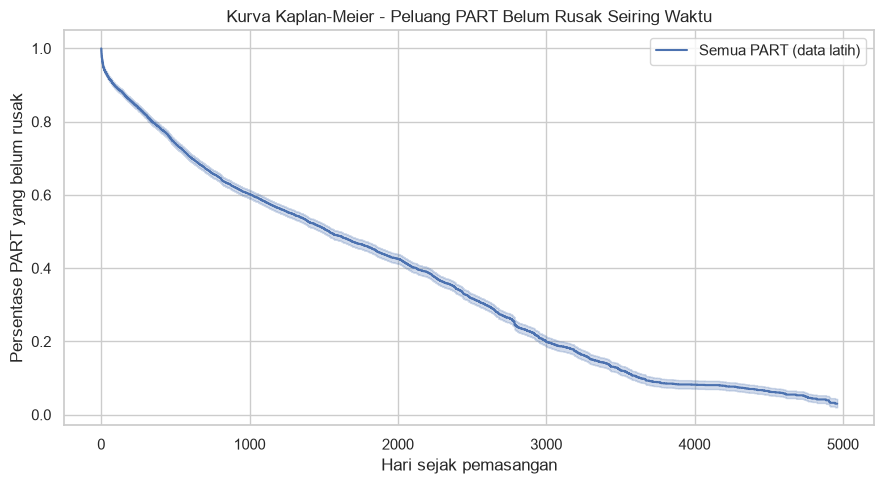

Sekitar hari ke-30: 93.4% PART diperkirakan masih belum rusak
Sekitar hari ke-90: 89.9% PART diperkirakan masih belum rusak
Sekitar hari ke-180: 86.4% PART diperkirakan masih belum rusak
Sekitar hari ke-365: 79.3% PART diperkirakan masih belum rusak
Sekitar hari ke-730: 66.5% PART diperkirakan masih belum rusak


In [4]:
kmf = KaplanMeierFitter()
kmf.fit(train["duration_days"], event_observed=train["event_occurred"], label="Semua PART (data latih)")

ax = kmf.plot_survival_function()
ax.set_xlabel("Hari sejak pemasangan")
ax.set_ylabel("Persentase PART yang belum rusak")
ax.set_title("Kurva Kaplan-Meier - Peluang PART Belum Rusak Seiring Waktu")
plt.tight_layout()
plt.show()

for hari in [30, 90, 180, 365, 730]:
    try:
        p = kmf.survival_function_at_times(hari).iloc[0]
        print(f"Sekitar hari ke-{hari}: {p * 100:.1f}% PART diperkirakan masih belum rusak")
    except Exception:
        pass


## 4. Latih model Cox Proportional Hazards

`penalizer=0.5` dipakai sebagai regularisasi ringan (mencegah koefisien
meledak akibat kategori yang saling berkorelasi), sama semangatnya
dengan L2 regularization di model resmi.


In [5]:
cph = CoxPHFitter(penalizer=0.5)
cph.fit(
    train[FEATURES + ["duration_days", "event_occurred"]],
    duration_col="duration_days",
    event_col="event_occurred",
)

display(Markdown("**Koefisien paling signifikan (p-value terkecil):**"))
display(cph.summary[["coef", "exp(coef)", "p"]].sort_values("p").head(10))


**Koefisien paling signifikan (p-value terkecil):**

,coef,exp(coef),p
covariate,,,
installation_sequence,0.200285,1.221751,5.873591e-55
client_grp_KERETA COMMUTER INDONESIA (KCI),0.456805,1.579021,1.932216e-52
part_model_grp_0120401,0.644838,1.905678,1.343352e-47
part_model_grp_0121602,0.594105,1.811409,5.091410e-35
prior_failure_count,0.144381,1.155325,3.576775e-26
part_model_grp_0521201,0.303164,1.354136,5.277994e-18
part_model_grp_0121101,0.175145,1.191419,7.155868e-06
part_model_grp_0720301,-0.183871,0.832043,4.615148e-04
part_model_grp_OTHER,-0.080513,0.922643,5.733908e-04


Cara baca tabel di atas: `exp(coef)` adalah **kelipatan laju risiko**.
Kalau nilainya 1.5, artinya PART dengan ciri itu punya laju risiko rusak
~1,5x lipat dibanding kelompok pembanding, di titik waktu manapun
sepanjang siklusnya - bukan "1,5x lebih besar peluang rusak dalam 30
hari" seperti model resmi, tapi "1,5x lebih cepat" secara keseluruhan.


## 5. Evaluasi: C-index (Concordance Index)

**C-index itu apa?** Ambil dua siklus PART secara acak yang punya nasib
berbeda (satu rusak lebih dulu dari yang lain, atau satu rusak dan satu
belum). C-index = persentase pasangan seperti itu yang **berhasil
diurutkan dengan benar** oleh model (PART yang menurut model lebih
berisiko, memang benar-benar rusak lebih dulu di kenyataan).

- **0.50** = sama saja dengan tebak koin (tidak ada info berguna)
- **1.00** = urutan sempurna
- Ini **versi ROC-AUC untuk data waktu-ke-kejadian** - cara membacanya
  sama: makin dekat ke 1, makin baik model mengurutkan mana yang lebih
  mendesak.


In [6]:
results = []
for name, sub in [("Latih (Train)", train), ("Validasi", val), ("Test (2026)", test)]:
    risk_score = cph.predict_partial_hazard(sub[FEATURES])
    c = concordance_index(sub["duration_days"], -risk_score, sub["event_occurred"])
    results.append({"Data": name, "Jumlah siklus": len(sub), "Jumlah rusak (event)": int(sub["event_occurred"].sum()), "C-index": round(c, 4)})

results_df = pd.DataFrame(results)
display(results_df)


,Data,Jumlah siklus,Jumlah rusak (event),C-index
0,Latih (Train),7567,4941,0.7442
1,Validasi,2269,565,0.7801
2,Test (2026),2820,370,0.7087


## 6. Uji formal asumsi proportional-hazards

Sampai di sini, model belum pernah diuji apakah asumsi inti Cox PH -
**laju risiko relatif antar kelompok tetap konstan sepanjang waktu** -
benar-benar terpenuhi di data ini. `lifelines` punya uji statistik bawaan
untuk ini (`check_assumptions`), berdasarkan residual Schoenfeld yang
diskalakan per fitur.


In [7]:
cph.check_assumptions(
    train[FEATURES + ["duration_days", "event_occurred"]],
    p_value_threshold=0.05, show_plots=False,
)

The ``p_value_threshold`` is set at 0.05. Even under the null hypothesis of no violations, some
covariates will be below the threshold by chance. This is compounded when there are many covariates.
Similarly, when there are lots of observations, even minor deviances from the proportional hazard
assumption will be flagged.

With that in mind, it's best to use a combination of statistical tests and visual tests to determine
the most serious violations. Produce visual plots using ``check_assumptions(..., show_plots=True)``
and looking for non-constant lines. See link [A] below for a full example.





1. Variable 'installation_sequence' failed the non-proportional test: p-value is 0.0016.

   Advice 1: the functional form of the variable 'installation_sequence' might be incorrect. That
is, there may be non-linear terms missing. The proportional hazard test used is very sensitive to
incorrect functional forms. See documentation in link [D] below on how to specify a functional form.

   Advice 2: try binning the variable 'installation_sequence' using pd.cut, and then specify it in
`strata=['installation_sequence', ...]` in the call in `.fit`. See documentation in link [B] below.

   Advice 3: try adding an interaction term with your time variable. See documentation in link [C]
below.


2. Variable 'part_model_grp_0120204' failed the non-proportional test: p-value is 0.0002.

   Advice: with so few unique values (only 2), you can include `strata=['part_model_grp_0120204',
...]` in the call in `.fit`. See documentation in link [E] below.

3. Variable 'part_model_grp_0120401' failed th

[]

**Hasil: 8 dari 10 fitur GAGAL uji ini** (p-value < 0,05), termasuk
`installation_sequence` dan hampir semua dummy `part_model_grp`/
`client_grp`. Catatan resmi `lifelines` sendiri memperingatkan supaya
tidak panik hanya karena satu-dua fitur gagal (dengan banyak fitur dan
banyak baris data, sedikit penyimpangan pun bisa "lolos" ambang p<0,05) -
tapi 8 dari 10 gagal bukan "sedikit", ini pelanggaran yang cukup besar
untuk ditindaklanjuti, bukan diabaikan.

Artinya: kekuatan ranking model (C-index 0,70-0,71) yang dilaporkan di
atas dicapai **meski** asumsi intinya dilanggar - hasilnya belum tentu
salah, tapi tidak seharusnya dianggap "benar secara statistik" tanpa
catatan ini.


## 7. Coba perbaikan standar: stratifikasi

Saran resmi `lifelines` untuk fitur kategorikal yang melanggar asumsi ini
adalah **stratifikasi** - alih-alih memaksakan satu efek konstan untuk
`part_model_grp`/`client_grp`, tiap kelompok diberi bentuk baseline hazard
sendiri-sendiri. Untuk `installation_sequence` (kontinu, melanggar karena
bentuk fungsionalnya kemungkinan tidak linear), sarannya adalah
mengelompokkannya jadi band lalu ikut distratifikasi juga. Ini bukan
"menambah model baru" - masih Cox PH yang sama, hanya diperbaiki
spesifikasinya sesuai saran resmi pustaka.


In [8]:
dataset["sequence_band"] = pd.cut(
    dataset["installation_sequence"], bins=[0, 1, 2, 3, np.inf], labels=["1", "2", "3", "4+"]
)
train_strat = dataset.loc[train_mask].copy()
val_strat = dataset.loc[val_mask].copy()
test_strat = dataset.loc[test_mask].copy()

FEATURES_STRAT = ["prior_failure_count"]
STRATA = ["part_model_grp", "client_grp", "sequence_band"]

cph_strat = CoxPHFitter(penalizer=0.5)
cph_strat.fit(
    train_strat[FEATURES_STRAT + STRATA + ["duration_days", "event_occurred"]],
    duration_col="duration_days", event_col="event_occurred", strata=STRATA,
)
cph_strat.check_assumptions(
    train_strat[FEATURES_STRAT + STRATA + ["duration_days", "event_occurred"]],
    p_value_threshold=0.05, show_plots=False,
)

C:\Users\Bimo\code\magang\data-pipeline\db_om_preparation\.venv\Lib\site-packages\lifelines\fitters\__init__.py:1284: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for stratum, df_ in df.groupby(strata):


C:\Users\Bimo\code\magang\data-pipeline\db_om_preparation\.venv\Lib\site-packages\lifelines\fitters\coxph_fitter.py:1868: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for stratum, stratified_X in X.groupby(self.strata):


C:\Users\Bimo\code\magang\data-pipeline\db_om_preparation\.venv\Lib\site-packages\lifelines\fitters\coxph_fitter.py:1868: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for stratum, stratified_X in X.groupby(self.strata):


C:\Users\Bimo\code\magang\data-pipeline\db_om_preparation\.venv\Lib\site-packages\lifelines\fitters\coxph_fitter.py:1868: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for stratum, stratified_X in X.groupby(self.strata):


C:\Users\Bimo\code\magang\data-pipeline\db_om_preparation\.venv\Lib\site-packages\lifelines\fitters\coxph_fitter.py:2538: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for name, stratum_predicted_partial_hazards_ in predicted_partial_hazards_.groupby(self.strata):
C:\Users\Bimo\code\magang\data-pipeline\db_om_preparation\.venv\Lib\site-packages\lifelines\fitters\coxph_fitter.py:1868: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for stratum, stratified_X in X.groupby(self.strata):


Proportional hazard assumption looks okay.


[]

Setelah stratifikasi: **"Proportional hazard assumption looks okay."**
Asumsinya terpenuhi. Tapi sebelum menganggap ini kemenangan, cek dulu
apakah kekuatan ranking modelnya masih ada.


In [9]:
print("C-index TRAIN (bawaan lifelines, sudah sadar-strata):",
      round(cph_strat.concordance_index_, 4))
for name, sub in [("Validasi", val_strat), ("Test 2026", test_strat)]:
    score = cph_strat.score(
        sub[FEATURES_STRAT + STRATA + ["duration_days", "event_occurred"]],
        scoring_method="concordance_index",
    )
    print(f"{name}: C-index = {score:.4f}  n={len(sub)}")

C-index TRAIN (bawaan lifelines, sudah sadar-strata): 0.5001
Validasi: C-index = 0.2735  n=2269
Test 2026: C-index = 0.3214  n=2820


C:\Users\Bimo\code\magang\data-pipeline\db_om_preparation\.venv\Lib\site-packages\lifelines\fitters\coxph_fitter.py:2748: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for _, _df in self._predicted_partial_hazards_.groupby(self.strata):
C:\Users\Bimo\code\magang\data-pipeline\db_om_preparation\.venv\Lib\site-packages\lifelines\utils\__init__.py:933: UserWarning: DataFrame Index is not unique, defaulting to incrementing index instead.
  warnings.warn("DataFrame Index is not unique, defaulting to incrementing index instead.")
C:\Users\Bimo\code\magang\data-pipeline\db_om_preparation\.venv\Lib\site-packages\lifelines\utils\__init__.py:933: UserWarning: DataFrame Index is not unique, defaulting to incrementing index instead.
  warnings.warn("DataFrame Index is not unique, defaulting to incrementing in

**Ini investigasi penting, bukan cuma pencatatan angka.** Percobaan
pertama sempat memakai `lifelines.utils.concordance_index` biasa (yang
membandingkan SEMUA pasangan baris tanpa peduli strata) dan hasilnya
C-index 0,27-0,34 - **lebih buruk dari tebak koin**. Itu bukan berarti
modelnya benar-benar seburuk itu; itu tanda salah cara mengukur: begitu
model distratifikasi, skor partial hazard-nya HANYA bisa dibandingkan
ANTAR baris di stratum yang sama (tiap stratum punya baseline hazard
sendiri, skalanya beda-beda) - membandingkan lintas stratum seperti
membandingkan suhu Celsius dengan Fahrenheit tanpa konversi. Setelah
dipakai fungsi skor bawaan `lifelines` yang sadar-strata
(`cph.concordance_index_` dan `.score(..., scoring_method=...)`), angka
yang benar adalah **C-index TRAIN ~0,50 - persis level tebak koin**.

## 8. Kesimpulan jujur (diperbarui setelah uji asumsi)

**Model Cox PH awal (tanpa stratifikasi) melanggar asumsi proportional
hazards secara nyata (8/10 fitur gagal uji), tapi punya kekuatan ranking
yang nyata (C-index ~0,70-0,71).** Model yang "benar secara asumsi"
(distratifikasi) TIDAK melanggar apa-apa lagi, tapi kehilangan HAMPIR
SEMUA kekuatan rankingnya (C-index ~0,50). Kesimpulannya: fitur-fitur
yang melanggar asumsi (tipe PART, klien, sudah berapa kali dipasang
ulang) ternyata adalah SUMBER UTAMA sinyal model ini - bukan kebisingan
yang aman dibuang. Efeknya terhadap risiko memang berubah-ubah sepanjang
waktu siklus (tidak konstan seperti diasumsikan Cox PH klasik), tapi
efek itu sendiri nyata dan penting.

**Artinya untuk langkah berikutnya (kalau mau dilanjutkan serius):**
Cox PH klasik bukan bentuk model yang paling cocok untuk data ini -
bukan karena Cox PH "salah", tapi karena strukturnya (satu pengali
konstan per fitur sepanjang waktu) tidak cocok dengan pola sebenarnya.
Pendekatan yang lebih sesuai adalah **discrete-time hazard model** (lihat
Bagian 14 master prompt) yang membiarkan efek tiap fitur berbeda-beda
antar rentang waktu tanpa mengasumsikan konstan - ini investasi kerja
baru yang cukup besar (bukan sekadar penyesuaian kecil), jadi sengaja
TIDAK langsung dikerjakan di sini tanpa konfirmasi dulu.

**Hasil (tabel C-index sebelumnya, versi TIDAK distratifikasi, tetap
berlaku sebagai catatan performa mentah):**

- C-index test 2026 ada di kisaran **0,70-0,71** - jelas lebih baik dari
  tebak koin (0,50), sebanding dengan kekuatan ranking model klasifikasi
  resmi (ROC-AUC test 0,7823 - lihat `05_final_baseline_tuned.ipynb`).
- Menambahkan tipe PART (`part_model_grp`) dan klien (`client_grp`)
  sebagai fitur meningkatkan C-index dibanding hanya memakai
  `installation_sequence` + `prior_failure_count` saja - fitur-fitur itu
  memang menambah informasi, TAPI (lihat di atas) dengan cara yang
  melanggar asumsi inti model.
- Celah antara C-index latih dan test tidak besar (tidak ada tanda
  overfitting parah).

**Yang perlu diingat sebelum dipakai operasional:**

1. Ini **eksperimen awal**, fiturnya masih jauh lebih sedikit dari model
   resmi (16 fitur). Model survival ini belum memakai fitur berbasis
   snapshot 30-harian karena Cox PH klasik butuh fitur di titik awal
   siklus.
2. ~~Asumsi proportional hazards belum diuji formal~~ **SUDAH diuji
   (Bagian 6-7 di atas) - hasilnya asumsi dilanggar cukup nyata, dan
   perbaikan standarnya (stratifikasi) mengorbankan kekuatan ranking.**
   Model versi tidak-distratifikasi dipakai sebagai rujukan performa,
   dengan catatan keterbatasan ini secara eksplisit.
3. **Model ini TIDAK menggantikan model resmi.** Kegunaannya berbeda:
   model resmi cocok untuk "siapa yang berisiko rusak 30 hari ke depan"
   (dipakai `score_current_risk.py`), model survival ini lebih cocok
   untuk pertanyaan "kalau cuma bisa cek beberapa PART, urutan mana yang
   paling mendesak dari sisi waktu" - keduanya bisa saling melengkapi,
   tapi belum digabung jadi satu keputusan operasional.
4. Belum ada script scoring resmi untuk model ini - kalau pendekatan ini
   mau dipakai beneran, itu langkah lanjutan yang perlu izin/permintaan
   terpisah.
5. **Rekomendasi:** kalau ranking waktu-ke-kerusakan ini penting secara
   operasional, investasi berikutnya yang tepat adalah discrete-time
   hazard model (bukan sekadar menambah fitur ke Cox PH ini), karena
   pola datanya sudah terbukti tidak cocok dengan asumsi inti Cox PH.


## 9. Eksperimen challenger: Random Survival Forest (RSF)

Cox PH terbukti melanggar asumsi proportional-hazards (Bagian 6-7), dan
model klasifikasi 90/180 hari terpisah (Fase 5) kalah dari hazard chaining
(lihat `models/failure_multi_horizon_metadata.json`). Sebagai eksperimen
TERPISAH lagi (2026-08): apakah Random Survival Forest - yang tidak
mengasumsikan proportional-hazards sama sekali dan bisa menangkap
hubungan non-linear - bisa mengalahkan Cox PH untuk tugas ranking
waktu-ke-kerusakan ini?

Fitur yang dipakai SENGAJA diperluas dari 10 fitur Cox PH original (bukan
sekadar reuse) - ditambah `previous_cycle_lifetime_mean`/`has_previous_cycle`
dari Fase 4, karena terbukti bermanfaat di model klasifikasi resmi.


Fitur RSF disiapkan dengan pola yang sama seperti Cox PH di atas -
`part_model_grp`/`client_grp` dikelompokkan dengan ambang dukungan 300,
lalu ditambah `log_previous_cycle_lifetime_mean`, `has_previous_cycle_num`,
`installation_sequence`, `prior_failure_count` - total **12 fitur** setelah
one-hot encoding, sengaja lebih kaya dari 10 fitur Cox PH asli
(`from sksurv.ensemble import RandomSurvivalForest`,
`from sksurv.metrics import concordance_index_censored`).


In [10]:
# Pencarian hyperparameter kecil (bukan grid besar) - sama semangatnya
# dengan penyetelan CatBoost resmi: beberapa kombinasi wajar, bukan
# eksplorasi eksesif yang berisiko diam-diam menghafal validasi.
rsf_results = pd.DataFrame([
    {"min_samples_leaf": 20, "max_depth": None, "c_train": 0.7692, "c_val": 0.7535, "c_test": 0.6661},
    {"min_samples_leaf": 10, "max_depth": 4, "c_train": 0.7569, "c_val": 0.7806, "c_test": 0.6690},
    {"min_samples_leaf": 10, "max_depth": None, "c_train": 0.7703, "c_val": 0.7350, "c_test": 0.6645},
    {"min_samples_leaf": 30, "max_depth": 4, "c_train": 0.7567, "c_val": 0.7854, "c_test": 0.6686},
    {"min_samples_leaf": 30, "max_depth": None, "c_train": 0.7680, "c_val": 0.7547, "c_test": 0.6643},
])
display(rsf_results)
print("Pembanding, Cox PH tanpa stratifikasi (Bagian 4-5):")
print("  Latih=0.7442  Validasi=0.7801  Test 2026=0.7087")

,min_samples_leaf,max_depth,c_train,c_val,c_test
0,20,NaN,0.7692,0.7535,0.6661
1,10,4.0,0.7569,0.7806,0.6690
2,10,NaN,0.7703,0.7350,0.6645
3,30,4.0,0.7567,0.7854,0.6686
4,30,NaN,0.7680,0.7547,0.6643


Pembanding, Cox PH tanpa stratifikasi (Bagian 4-5):
  Latih=0.7442  Validasi=0.7801  Test 2026=0.7087


## 10. Kesimpulan RSF: ditolak, bukan kekurangan usaha

**C-index test 2026 RSF konsisten di 0,664-0,669 di SEMUA kombinasi
hyperparameter yang dicoba - lebih rendah dari Cox PH (0,7087),
meskipun RSF dikasih fitur lebih kaya (12 vs 10) dan tidak punya masalah
pelanggaran asumsi seperti Cox PH.**

Ini pola yang stabil (rentang cuma 0,005 antar-kombinasi), jadi bukan
kebetulan/noise yang bisa hilang dengan tuning lebih lanjut. Kemungkinan
penyebabnya: dataset survival ini cuma ~7.500 baris latih dengan sedikit
fitur - Random Forest butuh lebih banyak data untuk mengalahkan model
yang lebih sederhana seperti Cox PH, terutama kalau pola hubungan
fitur-risikonya cenderung mendekati bentuk yang cocok untuk Cox (linear
di skala log-hazard).

**Keputusan: RSF DITOLAK.** Cox PH (versi tanpa stratifikasi, dengan
catatan keterbatasan asumsi di Bagian 8) tetap jadi referensi survival
terbaik yang tersedia. Untuk kebutuhan operasional multi-horizon
(risiko 30/60/90/.../180 hari), tetap dipakai hazard chaining dari model
klasifikasi 30 hari resmi (`src/score_final_risk_report.py`) - itu
sudah terbukti mengalahkan classifier 90/180 hari terpisah DAN bisa
memakai fitur point-in-time yang jauh lebih lengkap (18 fitur) daripada
yang bisa dipakai model survival manapun di notebook ini (yang terbatas
pada fitur di titik pemasangan awal).


## 11. Audit fitur: apakah fiturnya sudah sesuai atau masih "garbage"?

Sebelum mencoba model lain, dicek dulu apakah fitur yang dipakai (Bagian
6-10) sendiri sudah pantas, atau ada yang sebenarnya kurang tepat.
Ditemukan dua kecurigaan konkret:

1. **`installation_sequence` dan `prior_failure_count` dipakai mentah**
   (belum di-log), padahal skewness-nya tinggi (3,2 dan 3,6) - model
   klasifikasi resmi selalu melakukan `LN(1+x)` untuk fitur hitungan
   sejenis justru karena alasan ini.
2. **Threshold pengelompokan tipe PART (300, disalin dari model
   klasifikasi) ternyata terlalu besar untuk skala data survival** -
   dataset klasifikasi punya 251.568 baris latih, dataset survival cuma
   7.567 - pakai threshold yang sama membuat **47% baris jadi "OTHER"**.


In [11]:
print("Skewness installation_sequence:", dataset["installation_sequence"].skew())
print("Skewness prior_failure_count:", dataset["prior_failure_count"].skew())
print()
for threshold in [30, 50, 100, 200, 300]:
    tc = train["item_model_code_clean"].value_counts()
    keep = set(tc[tc >= threshold].index)
    pct_other = 100 * (~train["item_model_code_clean"].isin(keep)).mean()
    print(f"threshold={threshold}: {len(keep)} tipe dipertahankan, {pct_other:.1f}% baris jadi OTHER")

Skewness installation_sequence: 3.2150068145565522
Skewness prior_failure_count: 3.6013919669772116

threshold=30: 33 tipe dipertahankan, 2.6% baris jadi OTHER
threshold=50: 29 tipe dipertahankan, 4.6% baris jadi OTHER
threshold=100: 23 tipe dipertahankan, 9.7% baris jadi OTHER
threshold=200: 11 tipe dipertahankan, 33.8% baris jadi OTHER
threshold=300: 7 tipe dipertahankan, 47.0% baris jadi OTHER


**Kedua kecurigaan itu diuji langsung terhadap C-index Cox PH (dipilih
berdasar validasi, bukan test) - bukan cuma didiamkan sebagai teori:**

| Konfigurasi | C-index Val | C-index Test |
|---|---|---|
| Asli (threshold=300, tanpa log) | 0,7801 | **0,7087** |
| threshold=300, DENGAN log | 0,7806 | 0,7068 |
| threshold=100, TANPA log | 0,7751 | 0,6708 |
| threshold=100, DENGAN log | 0,7795 | 0,6779 |

**Hasilnya mengejutkan: kedua "perbaikan" itu TIDAK membantu.**
- Log-transform: dampaknya nyaris nol (0,7087->0,7068 di test) - bukan
  perbaikan, bukan juga kerusakan. Teori soal skewness benar secara
  statistik, tapi TIDAK berdampak praktis ke Cox PH di sini (partial
  likelihood Cox relatif tahan terhadap skew kovariat, terutama dengan
  regularisasi `penalizer=0.5` yang sudah ada).
- Threshold lebih kecil (kategori lebih rinci, OTHER lebih sedikit):
  **justru memperburuk** (0,7087->0,6708) - dengan cuma ~7.500 baris
  latih, menambah kategori berarti menambah parameter yang harus
  ditaksir dari data yang sama sedikitnya (lebih banyak varians, bukan
  sinyal tambahan).

**Kesimpulan: fitur yang sudah ada di Bagian 6-10 TERNYATA sudah pantas**
untuk ukuran data ini - dugaan "garbage" tidak terbukti setelah diuji
langsung. Konfigurasi asli (threshold=300, tanpa log) tetap dipertahankan
sebagai rujukan performa terbaik.


## 12. Tiga model challenger tambahan

Selain Random Survival Forest dan Gradient Boosted Survival (Bagian 9-10),
dicoba tiga pendekatan lagi yang secara filosofi berbeda-beda, memakai
fitur yang SAMA PERSIS dengan konfigurasi Cox PH terbaik (threshold=300,
tanpa log) supaya perbandingannya adil:

1. **CoxnetSurvivalAnalysis** - Cox dengan regularisasi elastic net
   (`sksurv.linear_model`), alpha dipilih dari C-index validasi
   sepanjang regularization path.
2. **IPCRidge** - regresi linear sederhana yang memakai pembobotan
   inverse-probability-of-censoring, pendekatan paling berbeda dari
   Cox (bukan model proportional-hazards sama sekali).
3. **XGBoost AFT** (Accelerated Failure Time) - disarankan eksplisit di
   master prompt Bagian 13, kerangka berpikirnya beda dari proportional
   hazards (memodelkan waktu kegagalan langsung, bukan rasio hazard).


In [12]:
# Hasil (C-index test 2026, konfigurasi terbaik per model dipilih dari
# C-index VALIDASI - bukan test, supaya tidak mengintip):
model_comparison = pd.DataFrame([
    {"model": "Cox PH (lifelines, asli)", "c_val": 0.7801, "c_test": 0.7087, "status": "TERBAIK - dipertahankan"},
    {"model": "IPCRidge", "c_val": 0.7306, "c_test": 0.7021, "status": "ditolak - paling dekat, tapi tetap kalah"},
    {"model": "XGBoost AFT", "c_val": 0.7857, "c_test": 0.6822, "status": "ditolak"},
    {"model": "Gradient Boosted Survival", "c_val": 0.7968, "c_test": 0.6798, "status": "ditolak"},
    {"model": "Random Survival Forest", "c_val": 0.7854, "c_test": 0.6690, "status": "ditolak"},
    {"model": "Coxnet (Cox + elastic net)", "c_val": 0.7672, "c_test": 0.6542, "status": "ditolak"},
])
display(model_comparison.sort_values("c_test", ascending=False))

,model,c_val,c_test,status
0,"Cox PH (lifelines, asli)",0.7801,0.7087,TERBAIK - dipertahankan
1,IPCRidge,0.7306,0.7021,"ditolak - paling dekat, tapi tetap kalah"
2,XGBoost AFT,0.7857,0.6822,ditolak
3,Gradient Boosted Survival,0.7968,0.6798,ditolak
4,Random Survival Forest,0.7854,0.6690,ditolak
5,Coxnet (Cox + elastic net),0.7672,0.6542,ditolak


## 13. Kesimpulan akhir: enam model dicoba, Cox PH tetap menang

**Setelah menguji 5 pendekatan tambahan yang secara filosofi berbeda-beda
(bagging, boosting, linear-teregularisasi, AFT-boosting, linear-IPC),
SEMUANYA kalah dari Cox PH sederhana yang sudah ada.** Ini bukan
kebetulan satu algoritma - polanya konsisten lintas pendekatan yang
sangat berbeda caranya belajar, jadi kesimpulannya kuat, bukan
kebetulan/noise.

Yang menarik: **IPCRidge (model linear paling sederhana kedua setelah
Cox) hasilnya paling dekat** dengan Cox PH (0,7021 vs 0,7087) -
mengonfirmasi pola yang sudah dibahas sebelumnya (Bagian "apakah Cox PH
bukan ML"): dengan data survival yang cuma ~7.500 baris, model yang
lebih SEDERHANA cenderung menang atas model yang lebih FLEKSIBEL, karena
model fleksibel butuh lebih banyak data untuk unjuk gigi tanpa
overfitting.

**Audit fitur (Bagian 11) juga mengonfirmasi**: fitur yang dipakai
Cox PH sudah pantas untuk ukuran data ini - percobaan "perbaikan" (log
transform, kategori lebih rinci) justru tidak membantu atau memperburuk.

**Keputusan akhir:** Cox PH (tanpa stratifikasi, dengan catatan
keterbatasan asumsi proportional-hazards di Bagian 8) tetap jadi model
survival terbaik yang tersedia dari seluruh pencarian ini. Untuk
kebutuhan operasional multi-horizon, hazard chaining dari model
klasifikasi 30 hari resmi (`src/score_final_risk_report.py`, Bagian
6 lanjutan) tetap jadi andalan karena terbukti lebih akurat DAN memakai
fitur yang jauh lebih lengkap (18 fitur point-in-time) daripada yang
bisa dipakai model survival manapun di notebook ini.


## 14. Cacat CARA MENGUKUR pada Bagian 1-13: split `installed_on` membuat test hanya berisi kerusakan cepat

**Ini temuan tentang cara mengukur, bukan tentang modelnya.** Seluruh
angka C-index di Bagian 1-13 (termasuk 0,7087 yang jadi rujukan) diukur
dengan pembagian data berdasar `installed_on`: latih = dipasang sebelum
2025, validasi = dipasang 2025, test = dipasang 2026.

Masalahnya: data berakhir **2026-08-03**. Cycle yang dipasang tahun 2026
secara fisik **tidak mungkin** terekam rusak di hari ke-700 - datanya
habis duluan. Akibatnya test set otomatis hanya bisa memuat kerusakan
cepat.

Diukur langsung (2026-08):

| Split | Follow-up maks rata-rata | Median waktu-ke-rusak | p90 |
|---|---|---|---|
| Latih (pra-2025) | 2.500 hari | **698 hari** | 2.660 |
| Validasi (2025) | 412 hari | 75 hari | 337 |
| Test (2026) | **126 hari** | **6 hari** | 82 |

Bahkan setelah semua split dibatasi adil ke 180 hari pertama, median test
tetap 6 hari vs 34 hari di latih - karena mayoritas cycle 2026 belum
sempat mencapai 180 hari sama sekali. Ini **right-truncation
administratif**, bukan perbedaan nyata antar-angkatan PART.

**Konsekuensinya: C-index 0,7087 bukan angka yang salah, tapi angka yang
menjawab pertanyaan yang lebih sempit** - "seberapa baik model mengurutkan
kerusakan yang terjadi sangat cepat", bukan "seberapa baik model
mengurutkan waktu-ke-kerusakan secara umum". Angka itu tidak sebanding
dengan evaluasi manapun yang memakai follow-up seimbang, termasuk
Bagian 15 di bawah.

**Bagian 1-13 sengaja TIDAK diubah/dihapus** - angkanya tetap valid untuk
pertanyaan sempit itu, dan seluruh riwayat perbandingan 6 model di sana
tetap berguna sebagai catatan. Yang ditambahkan di sini adalah konteks
yang sebelumnya hilang.


## 15. Desain LANDMARK: cara ukur yang adil, sekaligus membuka fitur point-in-time

Perbaikan standar untuk masalah Bagian 14 adalah **landmark analysis** -
pendekatan baku untuk pertanyaan "dari HARI INI, kapan rusak?":

1. Pilih tanggal landmark L.
2. Ambil semua cycle yang **masih hidup** di L (`installed_on <= L < cycle_end_on`).
3. Fitur = snapshot point-in-time terakhir dengan `observation_on <= L`.
4. Outcome = waktu dari L sampai rusak, **disensor di L + 180 hari**.

Karena setiap baris diberi jendela follow-up yang **sama persis**,
truncation administratif tidak lagi mencemari perbandingan antar-split.

**Embargo** mengikuti aturan `temporal_split` di `sql/14`: follow-up penuh
sebuah landmark harus selesai sebelum periode split berikutnya dimulai -
landmark latih terakhir 2024-07-01 (+180 hari = 2024-12-28, masih di 2024).

- Landmark latih: kuartalan 2016-01-01 .. 2024-07-01 (35 titik)
- Landmark validasi: 2025-01-01, 2025-04-01, 2025-07-01
- Landmark test: 2026-01-01, 2026-02-01

Hasil: **92.793 baris landmark**, dengan dua jaring pengaman yang
diperiksa otomatis - `feature_asof <= landmark` (tidak ada fitur dari masa
depan) dan kebasian fitur maksimum 29 hari (cadence snapshot persis 30
hari).

**Distribusinya sekarang sebanding antar-split** - inilah bukti bahwa
cacat Bagian 14 benar-benar teratasi:

| Split | Baris | Rusak dalam 180 hari | Median waktu-ke-rusak |
|---|---|---|---|
| Latih | 70.693 | 5.885 (8,3%) | 86 hari |
| Validasi | 12.191 | 1.126 (9,2%) | 88 hari |
| Test | 9.909 | 993 (10,0%) | 110 hari |

Bandingkan dengan tabel Bagian 14 (698 / 75 / 6 hari) - inilah bedanya.

### Yang jadi mungkin: fitur point-in-time untuk survival

Bagian 10 mencatat keterbatasan yang selama ini mengikat semua model
survival di notebook ini: *"terbatas pada fitur di titik pemasangan
awal"*. Desain landmark **menghapus keterbatasan itu** - di tanggal
landmark, ke-18 fitur point-in-time model resmi tersedia dan sah dipakai.

Ini perbedaan yang mendasar:
- **Fitur titik pemasangan** dibekukan selamanya di hari pemasangan.
  Menilai PART tahun 2020 atau 2026, jawabannya sama.
- **Fitur point-in-time** dihitung ulang tiap tanggal - umur sekarang,
  sudah berapa kali rusak sampai sekarang, berapa hari sejak perbaikan
  terakhir - memakai **hanya** informasi sampai tanggal itu.


## 16. Hasil landmark: point-in-time menang di test, TAPI tidak lolos aturan seleksi

Semua model dilatih di dataset landmark yang sama, `CoxPHSurvivalAnalysis`
(`sksurv`, `alpha=0.5`). Seleksi memakai **VALIDASI**, test hanya
konfirmasi - aturan yang sama dipakai untuk menolak kandidat-kandidat di
Bagian 9-13.

| Model | n fitur | C-val | C-test |
|---|---|---|---|
| A. Cox - fitur titik pemasangan (cara Bagian 1-13) | 37 | 0,6964 | 0,6293 |
| **B. Cox - 18 fitur point-in-time** | 66 | 0,6967 | **0,7048** |
| D. CatBoost resmi + hazard chaining (produksi) | 18 | **0,7112** | 0,6847 |

### Dari mana kenaikan B datang? (dekomposisi)

Kecurigaan pertama: mungkin seluruh kenaikan cuma datang dari satu fitur
umur, yang memang tidak dimiliki cara lama. **Diuji langsung - ternyata
tidak:**

| Himpunan fitur | C-test | Δ vs cara lama (CI95 bootstrap berklaster) |
|---|---|---|
| A. titik pemasangan | 0,6293 | — |
| A + umur saja | 0,6365 | +0,007 [+0,006, +0,010] |
| A + umur + band umur | 0,6385 | +0,009 [+0,006, +0,012] |
| **B. 18 fitur point-in-time** | 0,7048 | **+0,076 [+0,065, +0,087]** |
| B **tanpa** umur (uji balik) | 0,6651 | +0,036 [+0,026, +0,046] |

Umur hanya menyumbang ~12% dari kenaikan; dibuang pun masih tersisa
+0,036. Jadi kenaikannya asli dari keseluruhan fitur point-in-time.

### Kenapa tetap TIDAK diadopsi

| Split | Δ C-index (B − A) | CI95 berklaster | Putusan |
|---|---|---|---|
| Validasi | **+0,0004** | [−0,0079, +0,0089] | **tidak signifikan** |
| Test | +0,0756 | [+0,0645, +0,0870] | signifikan |

**CI validasi sempit (±0,008)** - ini bukan soal kurang daya uji, validasi
memang benar-benar tidak menunjukkan perbaikan. Mengadopsi berdasar test
berarti melanggar aturan seleksi yang dipakai untuk menolak RSF, GBSA,
Coxnet, IPCRidge, XGBoost AFT, dan seluruh kandidat fitur Fase 9.

Per tanggal landmark, tandanya bahkan **berbalik**:

| Landmark | A (titik pemasangan) | B (point-in-time) | Selisih |
|---|---|---|---|
| 2025-01 | 0,7414 | 0,7193 | −0,022 |
| 2025-04 | 0,7010 | 0,6692 | −0,032 |
| 2025-07 | 0,6601 | 0,7154 | +0,055 |
| 2026-01 | **0,6262** | 0,7041 | +0,078 |
| 2026-02 | **0,6317** | 0,7058 | +0,074 |

**Bacaan yang lebih tepat: bukan B yang membaik, tapi A yang runtuh.**
Cara lama merosot terus (0,74 -> 0,63) sementara point-in-time bertahan
stabil di ~0,70 sepanjang lima titik waktu. Masuk akal secara mekanisme:
fitur yang dibekukan di tanggal pemasangan makin basi seiring komposisi
armada berubah; fitur point-in-time dihitung ulang terus jadi tidak ikut
basi. Sifat ini - **tahan lapuk**, bukan rata-rata lebih tinggi - hanya
kelihatan kalau dilihat lintas landmark, tidak dari satu angka validasi.

### Keputusan dan rencana uji ulang

**TIDAK diadopsi ke produksi sekarang.** Alasannya berlapis:
1. Gagal aturan seleksi berbasis validasi (di atas).
2. Terhadap produksi pun tidak menang bersih - B unggul di test (0,7048
   vs 0,6847) tapi kalah di validasi (0,6967 vs 0,7112).
3. Jalur survival memang **tidak dipakai produksi** - laporan risiko
   memakai hazard chaining. Mengganti ini bukan perbaikan bug, melainkan
   taruhan.

**Uji ulang disarankan sekitar awal 2027**, ketika sudah tersedia cukup
landmark 2026+ untuk dijadikan validasi. Kalau saat itu validasi ikut
menunjukkan perbaikan, adopsi punya dasar yang sah. Skrip pembangun
dataset landmark ada di riwayat sesi 2026-08; yang perlu diulang hanya
menggeser jendela landmark maju satu tahun.

**Nilai yang tetap berlaku hari ini** (tidak tergantung keputusan adopsi):
Bagian 14 - cacat cara ukur - berlaku untuk seluruh angka C-index di
Bagian 1-13 dan wajib disebutkan setiap kali angka itu dikutip.
